In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import scipy.stats as stats

warnings.filterwarnings('ignore')

### 1. Eksplorasi Data dan Feature Engineering

In [ ]:
df = pd.read_csv('/Users/gibranariq/Documents/project/sales-analysis/ecommerce.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554697,21166,COOK WITH WINE METAL SIGN,1,5/25/2011 17:31,2.08,14584,United Kingdom
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,7/24/2011 11:58,2.55,17114,United Kingdom
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,7/19/2011 12:54,1.65,15311,United Kingdom
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,7/13/2011 11:34,1.25,16843,United Kingdom
4,544450,21789,KIDS RAIN MAC PINK,3,2/20/2011 12:23,0.85,17811,United Kingdom
...,...,...,...,...,...,...,...,...
4865,571883,23263,SET OF 3 WOODEN HEART DECORATIONS,1,10/19/2011 13:58,1.25,14704,United Kingdom
4866,545530,21922,UNION STRIPE WITH FRINGE HAMMOCK,12,3/3/2011 13:45,6.95,17416,United Kingdom
4867,540458,21125,SET 6 FOOTBALL CELEBRATION CANDLES,12,1/7/2011 12:28,1.25,12501,Germany
4868,574289,22999,TRAVEL CARD WALLET VINTAGE LEAF,24,11/3/2011 15:16,0.42,17750,United Kingdom


In [4]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [5]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Dari pengecekan tidak terdapat null pada data

In [6]:
df.duplicated().sum()

0

Tidak terdapat data yang duplikat juga pada dataset ini.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 304.5+ KB


Di sini kalau kita perhatikan terdapat variabel InvoiceDate yang bertipe object, kita bisa ubah menjadi datetime agar lebih mudah untuk diolah

Seperti yang sudah kita cek sebelumnya tidak terdapat missing value dan duplikat pada dataset ini. Namun kita bisa melakukan beberapa feature engineering untuk membuat fitur baru yang mungkin bisa berguna untuk analisis selanjutnya.

Selanjutnya kita akan coba cek lebih dalam ke InvoiceDate sebelum kita convert ke datetime

In [8]:
df['InvoiceDate'].sample(20)

3278     11/6/2011 11:44
3587     11/8/2011 17:42
3966       6/3/2011 9:50
4793     10/7/2011 10:13
4291      5/3/2011 12:10
2114     12/6/2011 12:19
4328     5/19/2011 11:41
121       4/4/2011 13:38
209       7/8/2011 11:36
3127      8/1/2011 12:56
4281    11/23/2011 11:51
338      8/25/2011 15:12
4469      5/4/2011 10:15
954      9/16/2011 14:04
283       2/3/2011 18:08
1894     11/1/2011 12:34
3103    11/23/2011 14:53
1943     11/8/2011 10:26
810       5/8/2011 12:58
2420     4/13/2011 14:12
Name: InvoiceDate, dtype: object

In [9]:
df['InvoiceDate'].str.len().value_counts()

InvoiceDate
15    2701
16    1088
14    1025
13      56
Name: count, dtype: int64

In [10]:
# cek yang len invoice date yang 13
df[df['InvoiceDate'].str.len() == 14]['InvoiceDate'].head(20)

7     9/1/2011 16:30
11    5/5/2011 14:32
15    3/8/2011 12:19
19    9/5/2011 12:18
22    4/4/2011 14:41
23    3/8/2011 14:12
25    3/6/2011 11:28
26    3/18/2011 9:55
28    3/6/2011 12:46
35    7/6/2011 11:52
36    2/7/2011 13:50
38    8/4/2011 14:30
40    4/7/2011 11:59
52    7/7/2011 10:40
56    12/6/2010 9:52
57    2/7/2011 11:20
63    9/7/2011 11:43
64    3/25/2011 8:52
65    6/6/2011 13:46
67    8/4/2011 16:17
Name: InvoiceDate, dtype: object

Kalau diperhatikan sebenarnya format dari InvoiceDate ini sudah cukup konsisten dan aman untuk kita ke datetime

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],format='%m/%d/%Y %H:%M')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4870 non-null   int64         
 1   StockCode    4870 non-null   object        
 2   Description  4870 non-null   object        
 3   Quantity     4870 non-null   int64         
 4   InvoiceDate  4870 non-null   datetime64[ns]
 5   UnitPrice    4870 non-null   float64       
 6   CustomerID   4870 non-null   int64         
 7   Country      4870 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 304.5+ KB


Nah sudah berhasil kita ubah

In [12]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom
5,571046,23295,SET OF 12 MINI LOAF BAKING CASES,3,2011-10-13 13:35:00,0.83,18096,United Kingdom
6,537604,37446,MINI CAKE STAND WITH HANGING CAKES,8,2010-12-07 13:01:00,1.45,13488,United Kingdom
7,565200,23266,SET OF 3 WOODEN STOCKING DECORATION,1,2011-09-01 16:30:00,1.25,17576,United Kingdom
8,564167,85099F,JUMBO BAG STRAWBERRY,10,2011-08-23 13:50:00,2.08,17735,United Kingdom
9,562888,22485,SET OF 2 WOODEN MARKET CRATES,2,2011-08-10 11:58:00,12.75,14388,United Kingdom


Selanjutnya kita akan cek quantity dan produknya

In [13]:
# cek quantity, description, dan Revenue diurutkan dari quantity tertinggi
df.sort_values(by='Quantity', ascending=False)[['CustomerID', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice', 'Description']].head(20)

,CustomerID,StockCode,Quantity,InvoiceDate,UnitPrice,Description
1863,17450,85123A,992,2011-11-03 15:32:00,3.20,WHITE HANGING HEART T-LIGHT HOLDER
4580,18102,22189,972,2010-12-07 16:42:00,2.31,CREAM HEART CARD HOLDER
2400,16684,22985,800,2011-02-03 12:00:00,0.34,"WRAP, BILLBOARD FONTS DESIGN"
3799,14607,22102,720,2011-10-24 10:36:00,0.39,MIRROR MOSAIC T-LIGHT HOLDER
618,16000,23461,620,2011-12-07 12:15:00,3.30,SWEETHEART BIRD HOUSE
971,18092,15036,600,2011-04-26 12:16:00,0.72,ASSORTED COLOURS SILK FAN
4353,16210,21137,480,2010-12-16 14:29:00,3.39,BLACK RECORD COVER FRAME
2948,17404,21977,480,2011-03-14 13:25:00,0.55,PACK OF 60 PINK PAISLEY CAKE CASES
2044,16698,22084,320,2011-04-27 10:52:00,2.55,PAPER CHAIN KIT EMPIRE
2028,15769,22835,312,2011-08-24 12:52:00,4.25,HOT WATER BOTTLE I AM SO POORLY


Kalo kita liaht di sini terdapat product yang quantitynya sangat tinggi dan ini normal saja karena bisa saja customer akan menjual lagi produk tersebut atau memang mempunyai usaha yang membutuhkan produk tersebut. Namun, yang janggal di sini terdapat produk 'Manual', jika diperhatikan penulisannya beda dengan yg lain, product lain menggunakan kapital dan kode stocknya berupa angka sedangkan Manual tidak, ini perlu kita selidiki.

In [14]:
len_stock = df['StockCode'].str.len().value_counts()
len_stock

StockCode
5    4427
6     421
4      13
1       5
2       2
7       2
Name: count, dtype: int64

Ternyata terdapat kode stock yang janggal juga karena hanya terdiri di bawah 5 digit seperti pada umumnya. Maka akan kita cek:

In [15]:
# tampilkan masing-masing dataframe stockcode yang panjangnya 1, 2, 4, dan 7
for length in [1, 2, 4, 7]:
    print(f"StockCode dengan panjang {length}:")
    display(df[df['StockCode'].str.len() == length])
    print("\n")


StockCode dengan panjang 1:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
792,572656,M,Manual,288,2011-10-25 12:22:00,1.50,14607,United Kingdom
920,580956,M,Manual,4,2011-12-06 14:23:00,1.25,17841,United Kingdom
1827,549730,M,Manual,1,2011-04-11 16:35:00,1.50,15867,United Kingdom
4244,537804,M,Manual,12,2010-12-08 13:17:00,2.95,12748,United Kingdom
4447,576213,M,Manual,1,2011-11-14 12:47:00,1.25,18117,United Kingdom




StockCode dengan panjang 2:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1125,544934,C2,CARRIAGE,1,2011-02-25 09:01:00,50.0,13345,United Kingdom
2490,563911,C2,CARRIAGE,1,2011-08-21 12:39:00,50.0,16265,United Kingdom




StockCode dengan panjang 4:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
170,564329,POST,POSTAGE,2,2011-08-24 13:55:00,18.00,12569,Germany
585,537897,POST,POSTAGE,1,2010-12-09 10:37:00,18.00,12683,France
1047,551345,POST,POSTAGE,6,2011-04-28 09:03:00,15.00,14646,Netherlands
2328,578348,POST,POSTAGE,2,2011-11-24 09:34:00,18.00,12494,France
2540,580536,POST,POSTAGE,3,2011-12-04 16:07:00,18.00,12490,France
2867,581182,POST,POSTAGE,4,2011-12-07 15:56:00,28.00,12783,Portugal
3459,539466,POST,POSTAGE,4,2010-12-19 12:46:00,18.00,12668,Germany
3476,578126,POST,POSTAGE,1,2011-11-23 10:32:00,4.95,16900,United Kingdom
3493,545180,POST,POSTAGE,1,2011-02-28 14:42:00,18.00,12728,France
3516,559819,POST,POSTAGE,1,2011-07-12 16:58:00,18.00,12682,France




StockCode dengan panjang 7:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1713,542412,15056BL,EDWARDIAN PARASOL BLACK,3,2011-01-27 16:49:00,5.95,16725,United Kingdom
4451,541238,15056BL,EDWARDIAN PARASOL BLACK,2,2011-01-16 10:42:00,5.95,16746,United Kingdom


Kali kita dari deskripsinya sepertinya Postage dan carriage ini adalah semacam biaya kirim atau ongkos kirim sedangkan untuk Manual masih tidak diketahui, untuk itu saya memutuskan untuk mendropnya saja

In [16]:
# drop yang stockcodenya 'M', 'C2', dan 'POST' 
df = df[~df['StockCode'].isin(['M', 'C2', 'POST'])]
df['StockCode'].str.len().value_counts()

StockCode
5    4427
6     421
7       2
Name: count, dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4850 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4850 non-null   int64         
 1   StockCode    4850 non-null   object        
 2   Description  4850 non-null   object        
 3   Quantity     4850 non-null   int64         
 4   InvoiceDate  4850 non-null   datetime64[ns]
 5   UnitPrice    4850 non-null   float64       
 6   CustomerID   4850 non-null   int64         
 7   Country      4850 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 341.0+ KB


Kita cek apakah ada barang yang harganya 0

In [18]:
df[df['UnitPrice'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


Ternyata aman, karena bisa saja semisal ada harganya 0 itu bisa terdapt asumsi kalau barang diberikan gratis atau terdapat voucher

Selanjutnya kita cek negara-negara

In [19]:
df['Country'].value_counts()

Country
United Kingdom          4338
Germany                  118
EIRE                      90
France                    83
Switzerland               28
Netherlands               25
Spain                     25
Belgium                   21
Norway                    14
Portugal                  14
Australia                 13
Sweden                    12
Channel Islands            8
Finland                    7
Greece                     7
Austria                    7
Cyprus                     6
Japan                      5
Italy                      5
Unspecified                4
Denmark                    4
Singapore                  3
United Arab Emirates       2
Poland                     2
Canada                     2
Israel                     2
RSA                        1
Lebanon                    1
Iceland                    1
Brazil                     1
Malta                      1
Name: count, dtype: int64

Di sini terdapat negara "Unspecified", saya memutuskan untuk mendropnya saja karena tidak jelas negara apa yang dimaksud dan hanya sedikit juga datanya

In [20]:
df = df[~df['Country'].isin(['Unspecified'])]
df['Country'].value_counts()

Country
United Kingdom          4338
Germany                  118
EIRE                      90
France                    83
Switzerland               28
Netherlands               25
Spain                     25
Belgium                   21
Norway                    14
Portugal                  14
Australia                 13
Sweden                    12
Channel Islands            8
Greece                     7
Finland                    7
Austria                    7
Cyprus                     6
Japan                      5
Italy                      5
Denmark                    4
Singapore                  3
United Arab Emirates       2
Poland                     2
Canada                     2
Israel                     2
RSA                        1
Lebanon                    1
Iceland                    1
Brazil                     1
Malta                      1
Name: count, dtype: int64

In [21]:
df.shape

(4846, 8)

#### Feature Engineering

Sekarang sayan ingin membuat beberapa kolom baru dari kolom yang sudah ada untuk analisis lebih lanjut

Kita akan buat beberap kolom dari datetime yang mungkin akan dipakai untuk analisis nantinya

In [22]:
# buat kolom baru untuk jam, hari, bulan, dan tahun
df['Hour'] = df['InvoiceDate'].dt.hour
df['Day'] = df['InvoiceDate'].dt.day_name()
df["Month"] = df["InvoiceDate"].dt.month
df['Year'] = df['InvoiceDate'].dt.year
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Hour,Day,Month,Year
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,17,Wednesday,5,2011
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,11,Sunday,7,2011
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,12,Tuesday,7,2011
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,11,Wednesday,7,2011
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,12,Sunday,2,2011


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4846 entries, 0 to 4869
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4846 non-null   int64         
 1   StockCode    4846 non-null   object        
 2   Description  4846 non-null   object        
 3   Quantity     4846 non-null   int64         
 4   InvoiceDate  4846 non-null   datetime64[ns]
 5   UnitPrice    4846 non-null   float64       
 6   CustomerID   4846 non-null   int64         
 7   Country      4846 non-null   object        
 8   Hour         4846 non-null   int32         
 9   Day          4846 non-null   object        
 10  Month        4846 non-null   int32         
 11  Year         4846 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(3), object(4)
memory usage: 435.4+ KB


Kita convert bulan ke nama bulan

In [24]:
# Fungsi untuk mengkategorikan waktu
def konversi_nama_bulan(x):
    if x == 1:
        return 'Januari'
    elif x == 2:
        return 'Februari'
    elif x == 3:
        return 'Maret'
    elif x == 4:
        return 'April'
    elif x == 5:
        return 'Mei'
    elif x == 6:
        return 'Juni'
    elif x == 7:
        return 'Juli'
    elif x == 8:
        return 'Agustus'
    elif x == 9:
        return 'September'
    elif x == 10:
        return 'Oktober'
    elif x == 11:
        return 'November'
    else:
        return 'Desember'

Kolom month(numerik) sengaja tidak saya hilangkan untuk berjaga-jaga saja

In [25]:
df['MonthName'] = df['Month'].apply(konversi_nama_bulan)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Hour,Day,Month,Year,MonthName
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,17,Wednesday,5,2011,Mei
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,11,Sunday,7,2011,Juli
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,12,Tuesday,7,2011,Juli
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,11,Wednesday,7,2011,Juli
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,12,Sunday,2,2011,Februari


Sekarang kita coba buat segmentasi berdasarkan waktu pembelian ke tiga waktu, yaitu pagi, siang, dan malam.

In [26]:
def categorize_time(time):
    if time >= pd.to_datetime('05:00:00').time() and time < pd.to_datetime('11:00:00').time():
        return 'Pagi'
    elif time >= pd.to_datetime('11:00:00').time() and time < pd.to_datetime('15:00:00').time():
        return 'Siang'
    elif time >= pd.to_datetime('15:00:00').time() and time < pd.to_datetime('18:00:00').time():
        return 'Sore'
    else:
        return 'Malam'
df['TimeCategory'] = df['InvoiceDate'].dt.time.apply(categorize_time)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Hour,Day,Month,Year,MonthName,TimeCategory
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,17,Wednesday,5,2011,Mei,Sore
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,11,Sunday,7,2011,Juli,Siang
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,12,Tuesday,7,2011,Juli,Siang
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,11,Wednesday,7,2011,Juli,Siang
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,12,Sunday,2,2011,Februari,Siang


Kita cek tahun

In [27]:
df['Year'].value_counts()

Year
2011    4528
2010     318
Name: count, dtype: int64

Karena terdapat lebih dari satu tahun, saya akan membuat kolom yang menggabungkan tahun dengan bulannya

In [28]:
# Ubah format YearMonth jadi zero-padded (misal: 201101, 201102, dst)
df['YearMonth'] = df['Year'].astype(str) + df['Month'].astype(str).str.zfill(2)
df['YearMonth'].unique()

array(['201105', '201107', '201102', '201110', '201012', '201109',
       '201108', '201112', '201103', '201111', '201104', '201106',
       '201101'], dtype=object)

Selanjutnya kita buat kolom Revenue yang merupakan hasil perkalian antara Quantity dan UnitPrice. 

In [29]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Hour,Day,Month,Year,MonthName,TimeCategory,YearMonth,Revenue
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,17,Wednesday,5,2011,Mei,Sore,201105,2.08
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,11,Sunday,7,2011,Juli,Siang,201107,5.10
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,12,Tuesday,7,2011,Juli,Siang,201107,1.65
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,11,Wednesday,7,2011,Juli,Siang,201107,15.00
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,12,Sunday,2,2011,Februari,Siang,201102,2.55


In [30]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4846 entries, 0 to 4869
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   InvoiceNo     4846 non-null   int64         
 1   StockCode     4846 non-null   object        
 2   Description   4846 non-null   object        
 3   Quantity      4846 non-null   int64         
 4   InvoiceDate   4846 non-null   datetime64[ns]
 5   UnitPrice     4846 non-null   float64       
 6   CustomerID    4846 non-null   int64         
 7   Country       4846 non-null   object        
 8   Hour          4846 non-null   int32         
 9   Day           4846 non-null   object        
 10  Month         4846 non-null   int32         
 11  Year          4846 non-null   int32         
 12  MonthName     4846 non-null   object        
 13  TimeCategory  4846 non-null   object        
 14  YearMonth     4846 non-null   object        
 15  Revenue       4846 non-null   float64      

Next kita akan analisis kolom numerik

In [31]:
num_cols = ['Quantity', 'UnitPrice', 'Revenue']
df[num_cols].describe()

,Quantity,UnitPrice,Revenue
count,4846.000000,4846.000000,4846.000000
mean,12.932522,2.877288,22.762848
std,38.029653,4.580633,81.315135
min,1.000000,0.040000,0.120000
25%,2.000000,1.250000,4.250000
50%,5.000000,1.950000,11.250000
75%,12.000000,3.750000,19.800000
max,992.000000,145.000000,3174.400000


Terdapat tiga kolom numerik yang dapat kita analisis, yaitu Quantity, UnitPrice, dan Revenue

In [32]:
kolom_cek = ['Quantity', 'UnitPrice', 'Revenue']

def check_plot(df, variable):
    for variable in kolom_cek:        
        plt.figure(figsize=(16, 4))

        # histogram
        plt.subplot(1, 3, 1)
        sns.histplot(df[variable], bins=30, kde=True)
        plt.title('Histogram')

        # plot Q-Q
        plt.subplot(1, 3, 2)
        stats.probplot(df[variable], dist="norm", plot=plt)
        plt.ylabel('Variable quantiles')

        # box plot
        plt.subplot(1, 3, 3)
        sns.boxplot(y=df[variable])
        plt.title('Boxplot')
        
        plt.show()

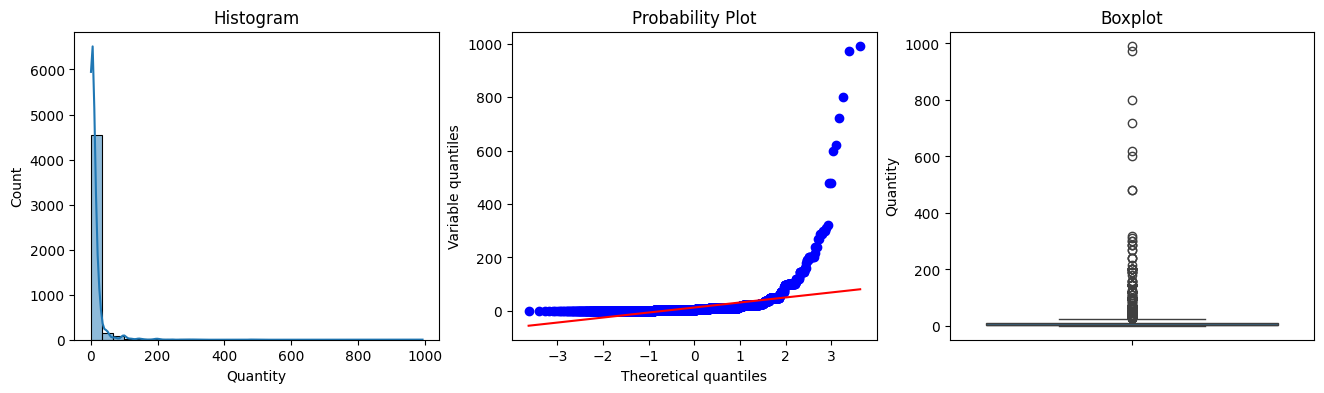

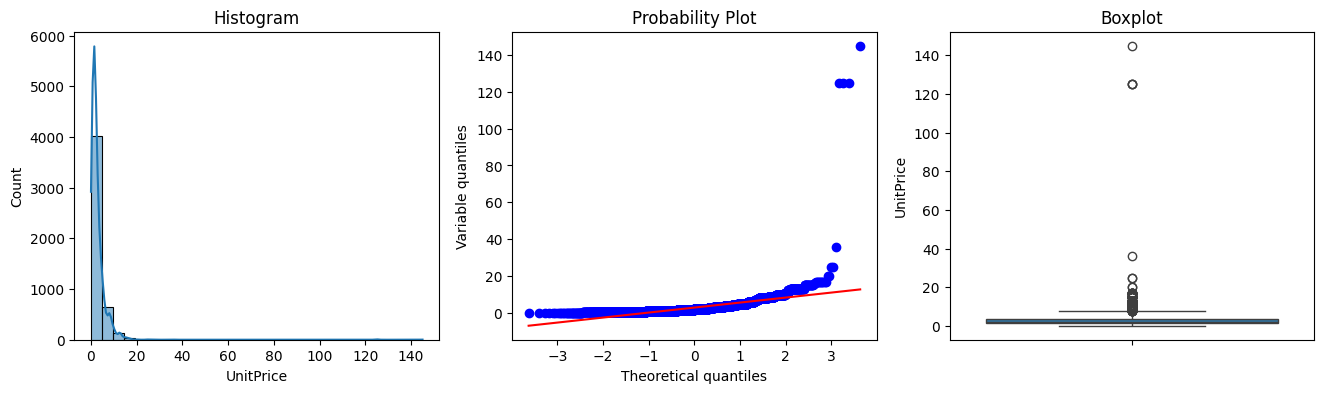

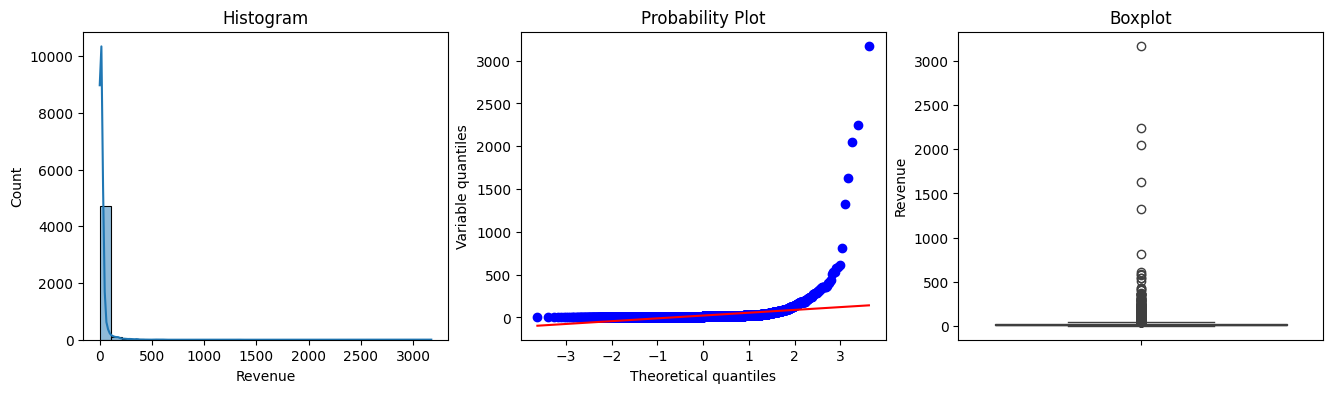

In [33]:
check_plot(df, kolom_cek)

Jika kita lihat grafik di atas, terdapat outlier di setiap datanya, di Quatity kemungkinan itu adalah data yang quantitynya tinggi-tinggi tadi sudah kita cek. Distribusi data juga cenderung menumpuk di sebelah kiri

In [34]:
# cek skewness apakah right skewed atau left skewed
for variable in kolom_cek:
    skewness = df[variable].skew()
    if skewness > 0:
        print(f"{variable} adalah right skewed dengan skewness: {skewness}")
    elif skewness < 0:
        print(f"{variable} adalah left skewed dengan skewness: {skewness}")
    else:
        print(f"{variable} adalah symmetric dengan skewness: {skewness}")

Quantity adalah right skewed dengan skewness: 13.972714635878711
UnitPrice adalah right skewed dengan skewness: 18.433190884832527
Revenue adalah right skewed dengan skewness: 22.89196835779827


Ini ketika kita periksa juga terbukti bahwa data sangat skewed ke kanan yang mana mean jauh lebih tinggi daripada median dan angka-angka kecil menumpuk di sebelah kiri sedangkan banyak angka besar yang tersebar ke sebelah kanan

Di sini saya tidak akan melakuan handle outlier atau drop outlier dikarenakan ini adalah data penjualan yang wajar saja jika ada transaksi yang besar, ditambah kita hanya melakukan EDA tidak melakukan prediksi menggunakan model jadi keputusan saya adalah untu tidak mendrop outlier. Saya meminta tolong dan bantuan kepada mentor, jika keputusan saya ini salah tolong berikan komentar agar saya tahu kl keputusan saya ini keliru. Terima kasih.

Selanjutnya kita cek korelasinya

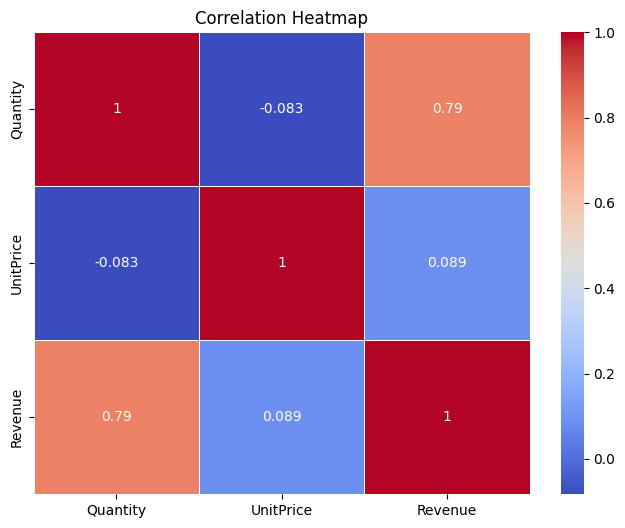

In [35]:
# heatmap untuk melihat korelasi antara quantity, unitprice, dan revenue
plt.figure(figsize=(8, 6))
sns.heatmap(df[kolom_cek].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Kalo dilihat Revenue pasti memang memiliki korelasi yang kuat dengan Quantityd dan UnitPrice karena Revenue dibuat oleh dua variabel tersebut. Yang bisa kita selidiki adalah korelasi UnitPrice dan Quantity adalah negatif, ini mendakdaan jika Quantity semakin banyak harga semakin berkurang. Dan memang benar saja setelah saya cek datanya langsung memang seperti itu nyatanya, asumsinya adalah ketika pelanggan membeli barang lebih banyak maka toko akan memberikan harga yang lebih murah untuk per barangnya, dan ini memang lumrah terjadi ketika jual beli di kehidupan nyata

#### Outlier (Tidak jadi dipakai)

In [36]:
# df_clean = df.copy()

In [37]:
# def find_outlier_boundary(df, variable):

#     # Mari kita hitung batas luar yang merupakan outlier

#     IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

#     lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
#     upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

#     return upper_boundary, lower_boundary

In [38]:
# full_occup_upper_limit, full_occup_lower_limit = find_outlier_boundary(df, kolom_cek)
# full_occup_upper_limit, full_occup_lower_limit

In [39]:
df.shape

(4846, 16)

In [40]:
# for col in kolom_cek:
#     upper_limit, lower_limit = find_outlier_boundary(df, col)
#     df = df[(df[col] <= upper_limit) & (df[col] >= lower_limit)]
#     print(f"Setelah filter {col}: {df.shape}")


In [41]:
df.shape

(4846, 16)

In [42]:
# check_plot(df, kolom_cek)   

### 2. Visualisasi dan Analisis

#### 1. Customer

1. Siapa top 5 customer dengan order terbanyak?

In [43]:
top_5_cust = df['CustomerID'].value_counts().head(5)
top_5_cust

CustomerID
17841    111
14911     76
12748     64
14096     57
14606     55
Name: count, dtype: int64

Kita bisa lihat customer dengan order terbanyak, sayangnya tidak ada data nama jadi kita tidak tahu persis siapa customernya

2. Siapa top 5 customer dengan spent terbanyak?

In [44]:
top_5_spent = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(5)
top_5_spent

CustomerID
17450    3521.44
15769    3509.00
14646    3479.53
18102    2940.42
14911    2149.65
Name: Revenue, dtype: float64

3. Berapa order pada setiap bulannya dari tahun 2010 - 2011?

In [45]:
tahun_2010 = df[df['Year'] == 2010]
tahun_2010.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Hour,Day,Month,Year,MonthName,TimeCategory,YearMonth,Revenue
6,537604,37446,MINI CAKE STAND WITH HANGING CAKES,8,2010-12-07 13:01:00,1.45,13488,United Kingdom,13,Tuesday,12,2010,Desember,Siang,201012,11.60
30,537888,22454,MEASURING TAPE BABUSHKA RED,6,2010-12-09 10:04:00,2.95,15358,United Kingdom,10,Thursday,12,2010,Desember,Pagi,201012,17.70
51,539728,22139,RETROSPOT TEA SET CERAMIC 11 PC,3,2010-12-21 14:26:00,4.95,16270,United Kingdom,14,Tuesday,12,2010,Desember,Siang,201012,14.85
56,537236,21531,RED RETROSPOT SUGAR JAM BOWL,24,2010-12-06 09:52:00,2.10,16858,United Kingdom,9,Monday,12,2010,Desember,Pagi,201012,50.40
91,537619,84970L,SINGLE HEART ZINC T-LIGHT HOLDER,12,2010-12-07 13:53:00,0.95,13786,United Kingdom,13,Tuesday,12,2010,Desember,Siang,201012,11.40


In [46]:
tahun_2010['MonthName'].value_counts()

MonthName
Desember    318
Name: count, dtype: int64

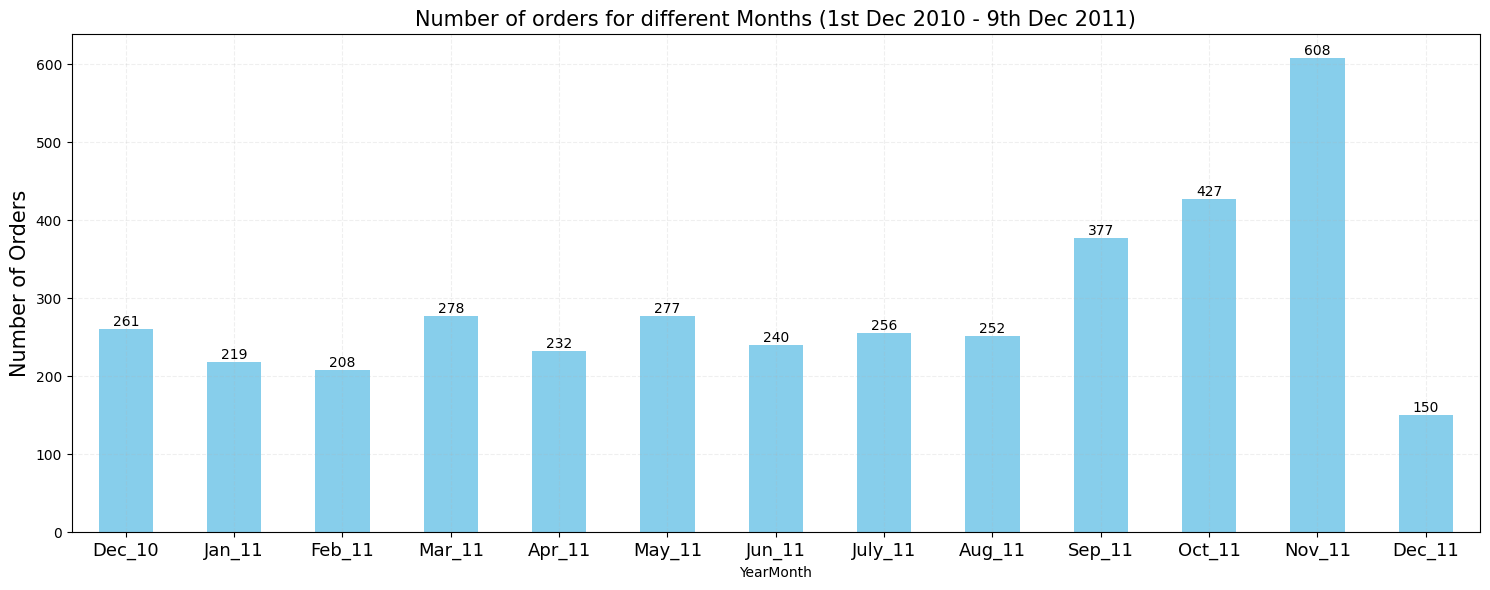

In [47]:
ax = df.groupby('InvoiceNo')['YearMonth'].unique().value_counts().sort_index().plot(kind='bar',color='skyblue',figsize=(15,6))
ax.set_ylabel('Number of Orders',fontsize=15)
ax.set_title('Number of orders for different Months (1st Dec 2010 - 9th Dec 2011)',fontsize=15)
ax.set_xticklabels(('Dec_10','Jan_11','Feb_11','Mar_11','Apr_11','May_11','Jun_11','July_11','Aug_11','Sep_11','Oct_11','Nov_11','Dec_11'), rotation='horizontal', fontsize=13)

# tampilin angka di atas bar
for p in ax.patches:
    ax.annotate(str(p.get_height()), 
    (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        fontsize=10, color='black', 
        xytext=(0, 5), 
        textcoords='offset points'
    )
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

Kita dapat melihat order pada tiap bulannya dari grafik di atas, kalo kita perhaikan di bukan November 2011 terjadi order tertinggi sepanjang penjualan

4. Kapan peak hour order biasanya terjadi?

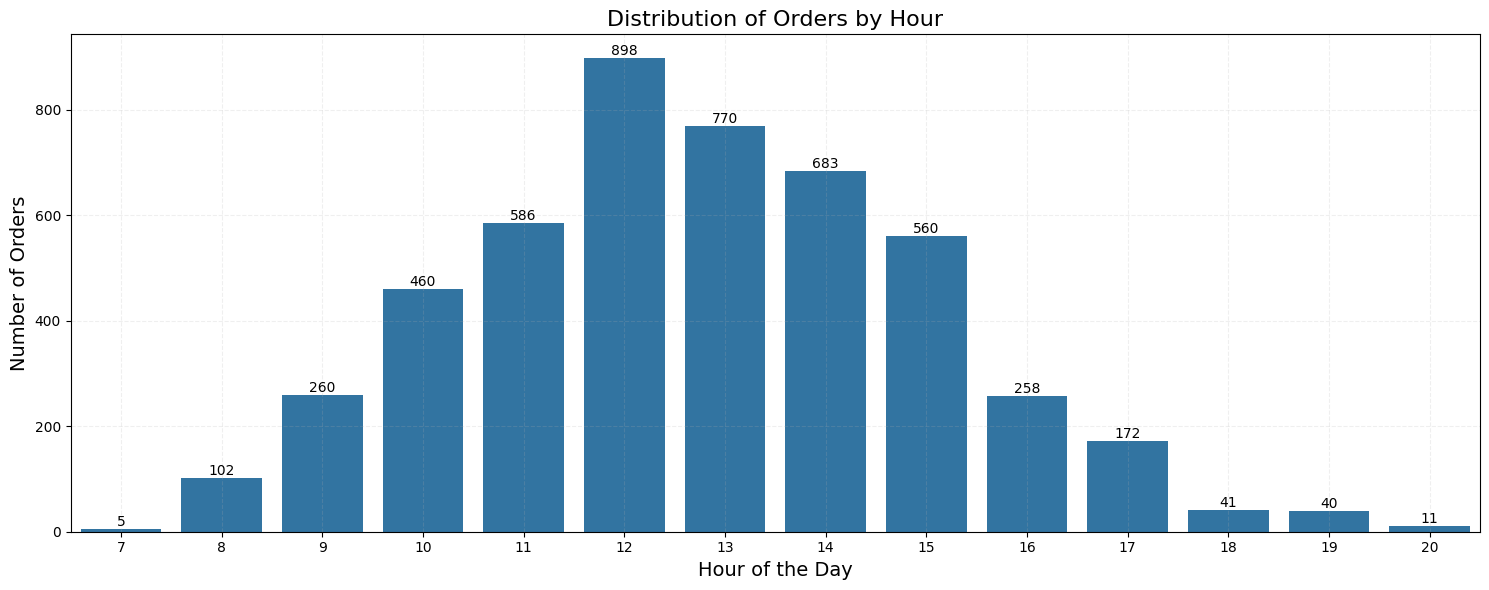

In [48]:
plt.figure(figsize=(15, 6))
ax = sns.countplot(x='Hour', data=df)
plt.title('Distribution of Orders by Hour', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()

# tampilin angka di atas bar
for p in ax.patches:
    ax.annotate(int(p.get_height()), 
    (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        fontsize=10, color='black', 
        xytext=(0, 5), 
        textcoords='offset points'
    )
plt.show()

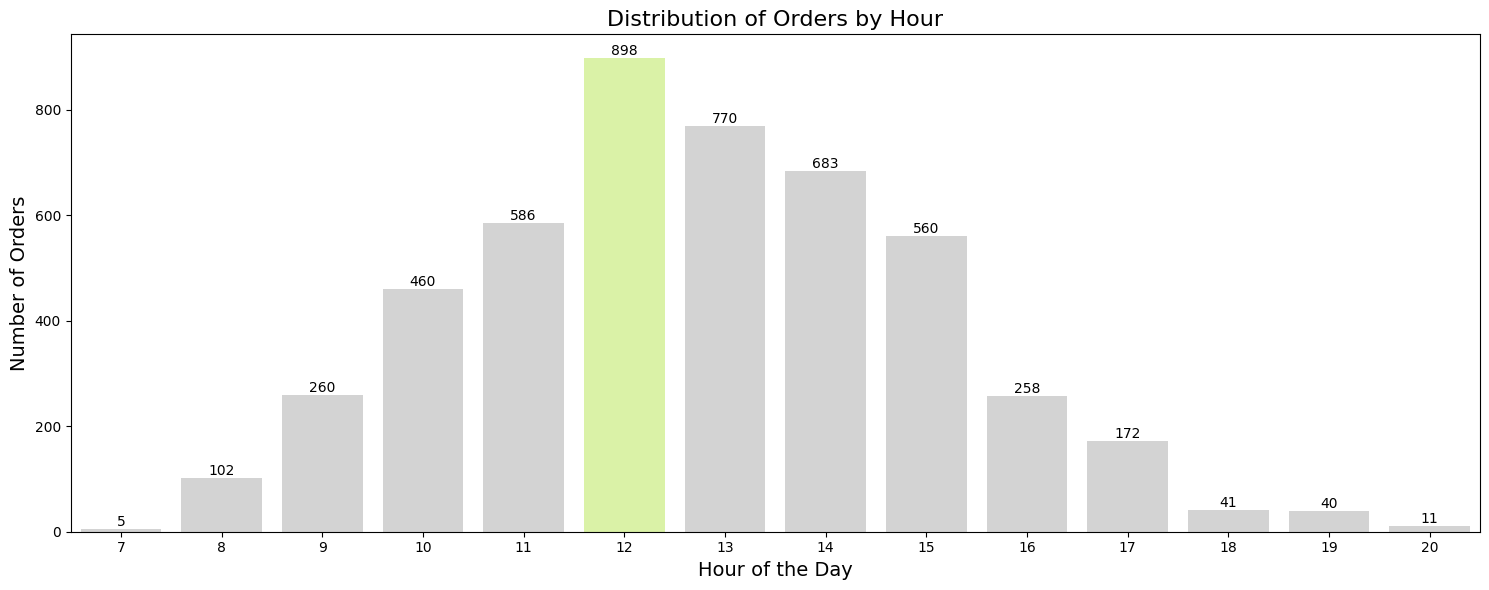

In [86]:
plt.figure(figsize=(15, 6))

# 1. Tentukan urutan jam yang akan ditampilkan
hour_order = sorted(df['Hour'].unique())

# 2. Buat custom palette warna (orange untuk jam 12, abu-abu untuk yang lain)
colors = ['#deff9a' if hour == 12 else '#d3d3d3' for hour in hour_order]

# 3. Plot dengan menyertakan palette warna & hue untuk menghindari warning di versi Seaborn terbaru
ax = sns.countplot(x='Hour', data=df, order=hour_order, hue='Hour', palette=colors, legend=False)

plt.title('Distribution of Orders by Hour', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)
# plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()

# Tampilin angka di atas bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Hanya menampilkan jika nilai bar lebih besar dari 0
        ax.annotate(int(height), 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='center', 
            fontsize=10, color='black', 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.show()


Pada grafik di atas dapat dikatakan orang-orang paling sering beli saat siang hari pukul jam 12 dan terus menurun hingga sore hari

5. Bagaimana distribusi order berdasarkan tiap negara?

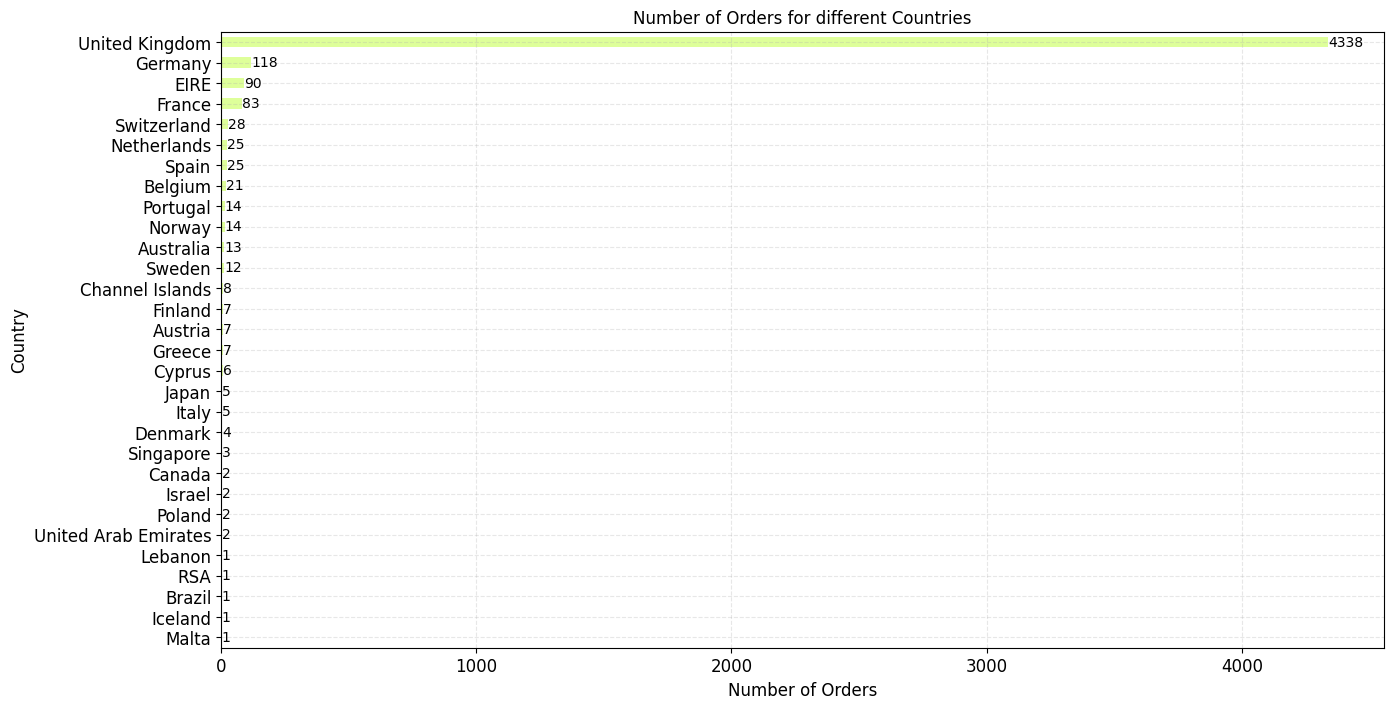

In [81]:
group_country_orders = df.groupby('Country')['InvoiceNo'].count().sort_values()
# del group_country_orders['United Kingdom']

# plot number of unique customers in each country (with UK)
plt.subplots(figsize=(15,8))
ax = group_country_orders.plot(kind='barh', fontsize=12, color='#deff9a')
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Number of Orders for different Countries', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# tambahin angka di atas bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center')
    
plt.show()

Kalau kita perhatikan negara UK sangat mendominasi data sehingga dapat dikatakan sama saja seperti kita menganalisis data dari negara UK, untuk itu saya mencoba untuk melihat distribusi tanpa negara UK

In [50]:
df_no_uk = df[df['Country'] != 'United Kingdom']
df_no_uk['Country'].value_counts()

Country
Germany                 118
EIRE                     90
France                   83
Switzerland              28
Netherlands              25
Spain                    25
Belgium                  21
Portugal                 14
Norway                   14
Australia                13
Sweden                   12
Channel Islands           8
Greece                    7
Finland                   7
Austria                   7
Cyprus                    6
Japan                     5
Italy                     5
Denmark                   4
Singapore                 3
United Arab Emirates      2
Poland                    2
Canada                    2
Israel                    2
RSA                       1
Lebanon                   1
Iceland                   1
Brazil                    1
Malta                     1
Name: count, dtype: int64

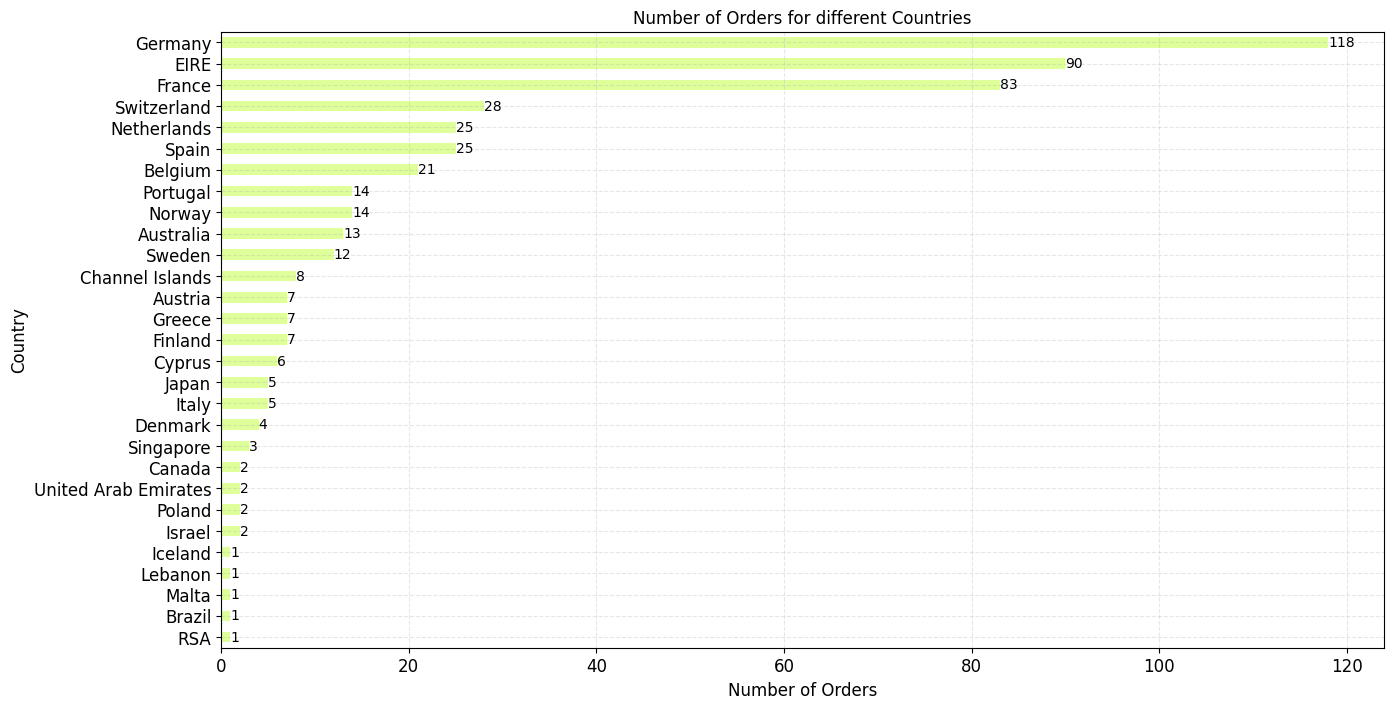

In [79]:
group_country_orders = df_no_uk.groupby('Country')['InvoiceNo'].count().sort_values()

# plot number of unique customers in each country (with UK)
plt.subplots(figsize=(15,8))
ax = group_country_orders.plot(kind='barh', fontsize=12, color='#deff9a')
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Number of Orders for different Countries', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# tambahin angka di atas bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center')
    
plt.show()

Nah sekarang lebih terlihat, tiga negara lainnya yang cukup tinggi adalah Germany, EIRE (irlandia), dan France

In [52]:
top_5_country = df['Country'].value_counts().head(5)
top_5_time_country = df[df['Country'].isin(top_5_country.index)].groupby(['Country', 'TimeCategory'])['InvoiceNo'].count().reset_index()
top_5_time_country.columns = ['Country', 'TimeCategory', 'Order']
top_5_time_country

,Country,TimeCategory,Order
0,EIRE,Malam,1
1,EIRE,Pagi,29
2,EIRE,Siang,49
3,EIRE,Sore,11
4,France,Pagi,24
5,France,Siang,49
6,France,Sore,10
7,Germany,Malam,1
8,Germany,Pagi,39
9,Germany,Siang,61


5. Bagaimana distribusi order berdasarkan waktu (pagi, siang, sore, malam) untuk 5 negara dengan order terbanyak?

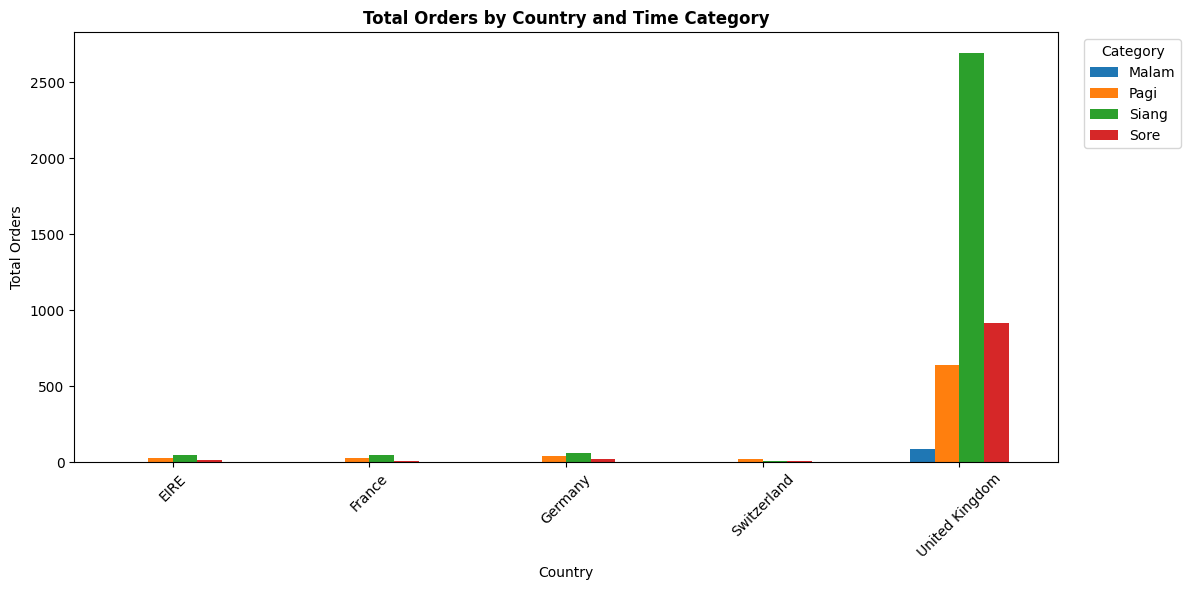

In [53]:
# Visualisasi sebagai pivot
pivot_sales = top_5_time_country.pivot(index='Country', columns='TimeCategory', values='Order')

plt.figure(figsize=(12, 6))
pivot_sales.plot(kind='bar', ax=plt.gca())
plt.title('Total Orders by Country and Time Category', fontweight='bold')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Ini saya akan membandingkan grafik dengan UK dan tidak, karena kalo dengan grafik di atas kita jadi tidak dapat melihat jelas bagaimana distribusinya dan sudah pasti UK sangat mendominasi. Di UK sendiri dapat kita lihat bahwa mayoritas pelanggan belanja pada siang hari

Sekarang kita cek yang tanpa UK

In [54]:
new_top_5_country = df_no_uk['Country'].value_counts().head(5)
new_top_5_country= df_no_uk[df_no_uk['Country'].isin(new_top_5_country.index)].groupby(['Country', 'TimeCategory'])['InvoiceNo'].count().reset_index()
new_top_5_country.columns = ['Country', 'TimeCategory', 'Order']
new_top_5_country

,Country,TimeCategory,Order
0,EIRE,Malam,1
1,EIRE,Pagi,29
2,EIRE,Siang,49
3,EIRE,Sore,11
4,France,Pagi,24
5,France,Siang,49
6,France,Sore,10
7,Germany,Malam,1
8,Germany,Pagi,39
9,Germany,Siang,61


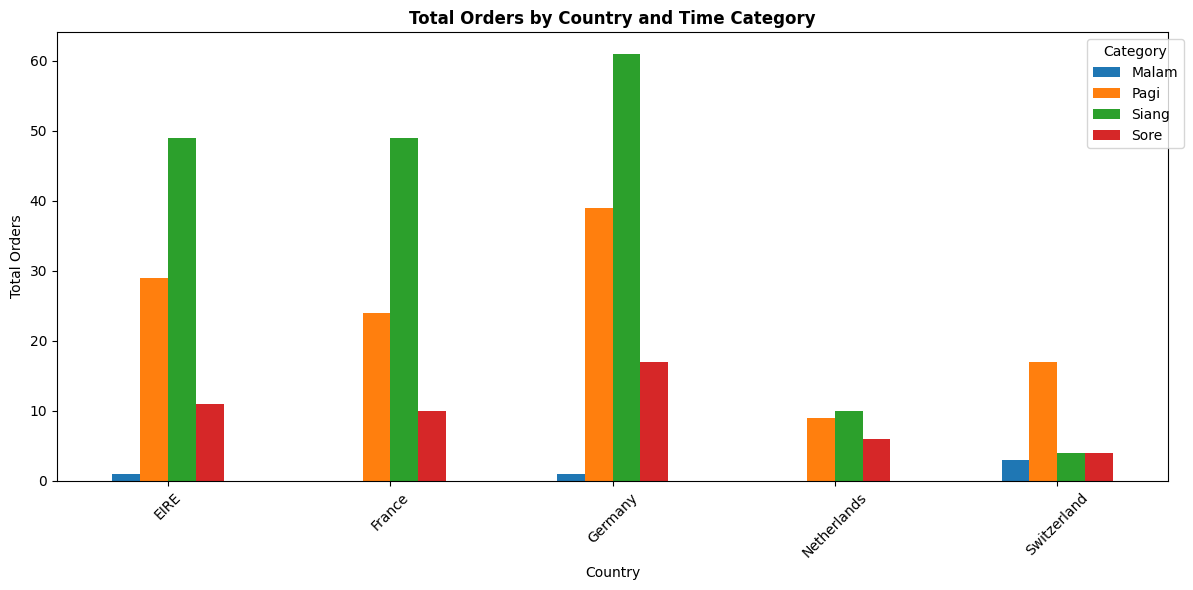

In [55]:
# Visualisasi sebagai pivot
pivot_sales = new_top_5_country.pivot(index='Country', columns='TimeCategory', values='Order')

plt.figure(figsize=(12, 6))
pivot_sales.plot(kind='bar', ax=plt.gca())
plt.title('Total Orders by Country and Time Category', fontweight='bold')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Nah sekarang sudah terlihat jelas, kalau kita perhatikan hampir semua negara dominan berbelanja pada siang hari, tetapi jika kita lihat di Swiss ternyata orang-orang lebih suka atau lebih sering berbelanja di pagi hari artinya toko di Swiss harus lebih memanfaatkan hal ini dengan bersiap lebih cepat di pagi hari dan membuat promo khusus misalnya

#### 2. Penjualan

1. Bulan dan tahun apa yang memiliki tingkat revenue tertinggi dari rentang Des 2010 - Des 2011?

In [56]:
revenue_monthly = df.groupby('YearMonth')['Revenue'].sum().sort_index()
revenue_monthly

YearMonth
201012    10685.15
201101     6247.52
201102     6084.46
201103     7162.64
201104     6068.13
201105     6987.24
201106     7132.93
201107     7542.72
201108     9799.41
201109     9761.11
201110     9745.38
201111    17906.64
201112     5185.43
Name: Revenue, dtype: float64

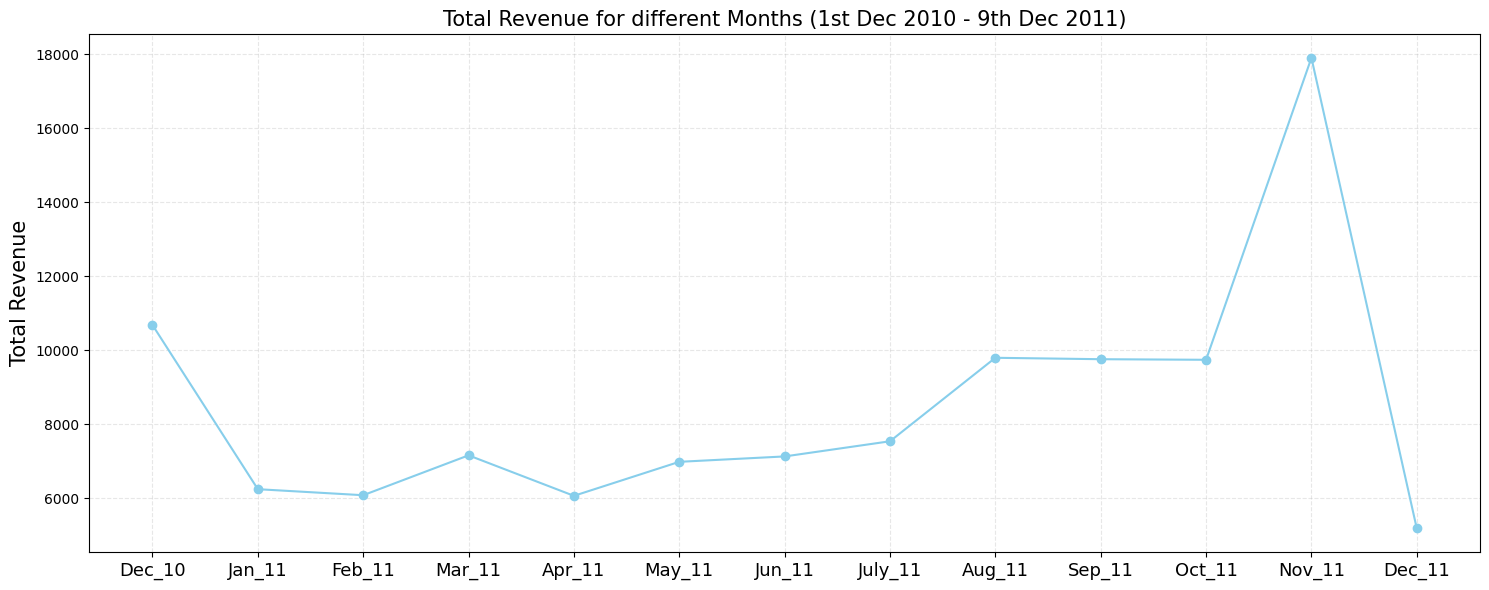

In [57]:
# total revenue per month
revenue_monthly = df.groupby('YearMonth')['Revenue'].sum().sort_index()

plt.figure(figsize=(15, 6))
plt.plot(range(len(revenue_monthly)), revenue_monthly.values, color='skyblue', marker='o')
plt.ylabel('Total Revenue', fontsize=15)
plt.title('Total Revenue for different Months (1st Dec 2010 - 9th Dec 2011)', fontsize=15)
plt.xticks(
    range(len(revenue_monthly)), 
    ['Dec_10','Jan_11','Feb_11','Mar_11','Apr_11','May_11','Jun_11',
     'July_11','Aug_11','Sep_11','Oct_11','Nov_11','Dec_11'],
    fontsize=13
)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

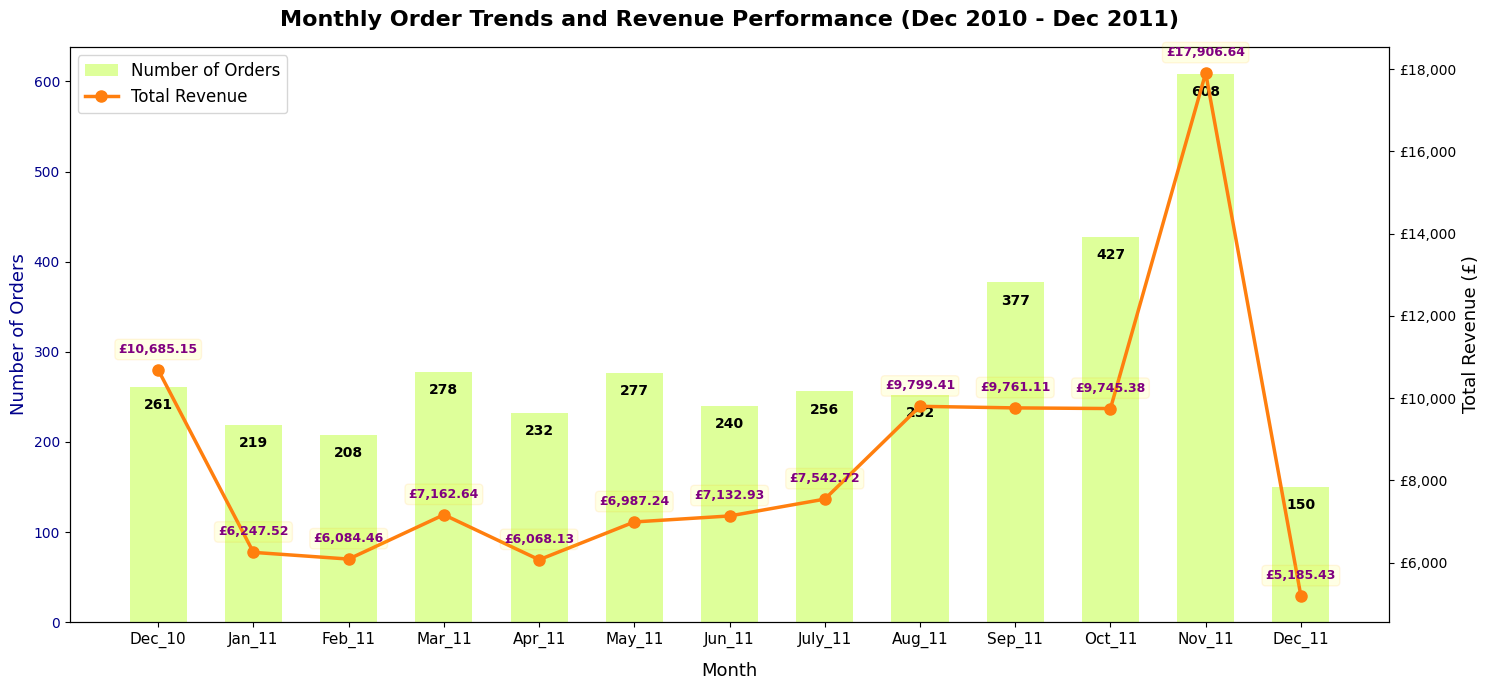

In [58]:
# Sel baru: Visualisasi Gabungan Jumlah Order & Total Revenue Bulanan (Dual-Axis Combo Chart)
import matplotlib.ticker as ticker

# Menyiapkan data secara terurut berdasarkan bulan
monthly_data = df.groupby('YearMonth').agg(
    Orders=('InvoiceNo', 'nunique'),
    Revenue=('Revenue', 'sum')
).sort_index()

months_labels = ['Dec_10','Jan_11','Feb_11','Mar_11','Apr_11','May_11','Jun_11','July_11','Aug_11','Sep_11','Oct_11','Nov_11','Dec_11']

# Membuat figure dan axes utama
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Bar Chart untuk Jumlah Order (Sumbu Y Utama - Kiri)
bars = ax1.bar(monthly_data.index, monthly_data['Orders'], color='#deff9a', label='Number of Orders', width=0.6)
ax1.set_xlabel('Month', fontsize=13, labelpad=10)
ax1.set_ylabel('Number of Orders', color='darkblue', fontsize=13)
ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.set_xticklabels(months_labels, rotation=0, fontsize=11)
ax1.set_xticks(range(len(monthly_data)))

# Tampilkan angka jumlah order di atas bar
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, -8),
                 textcoords="offset points",
                 ha='center', va='top', fontsize=10, fontweight='bold')

# Plot Line Chart untuk Revenue (Sumbu Y Kedua - Kanan)
ax2 = ax1.twinx()
line = ax2.plot(monthly_data.index, monthly_data['Revenue'], color='#ff7f0e', marker='o', linewidth=2.5, markersize=8, label='Total Revenue')
ax2.set_ylabel('Total Revenue (£)', color='black', fontsize=13)
ax2.tick_params(axis='y', labelcolor='black')

# Format angka mata uang pada sumbu Y kanan
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'£{x:,.0f}'))

# Tampilkan angka revenue di setiap titik line chart dengan penyorotan (highlighting)
for i, val in enumerate(monthly_data['Revenue']):
    ax2.annotate(f'£{val:,.2f}',
                 xy=(i, val),
                 xytext=(0, 10),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, color='purple', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.1, ec="orange"))

plt.title('Monthly Order Trends and Revenue Performance (Dec 2010 - Dec 2011)', fontsize=16, fontweight='bold', pad=15)
# ax1.grid(True, linestyle='--', alpha=0.3)

# Menampilkan legenda gabungan
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

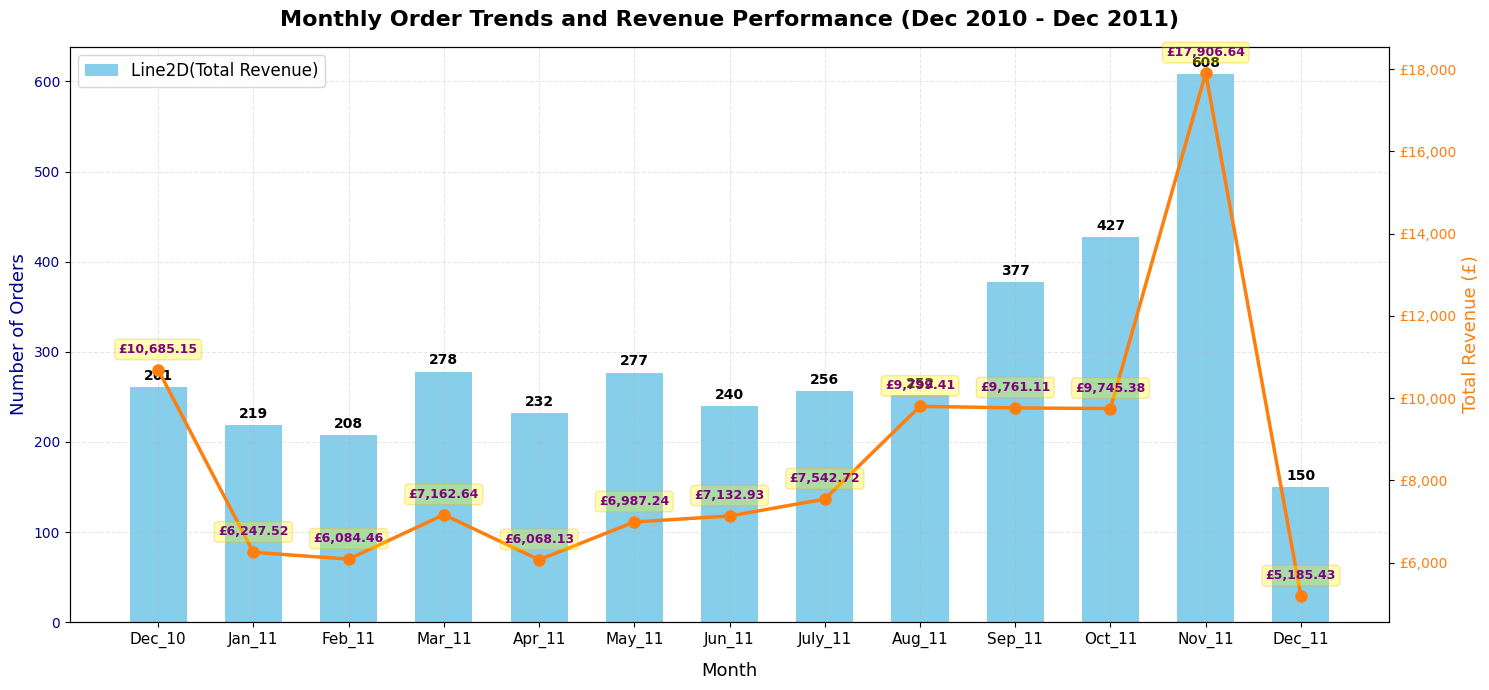

In [59]:
# Sel baru: Visualisasi Gabungan Jumlah Order & Total Revenue Bulanan (Dual-Axis Combo Chart)
import matplotlib.ticker as ticker

# Menyiapkan data secara terurut berdasarkan bulan
monthly_data = df.groupby('YearMonth').agg(
    Orders=('InvoiceNo', 'nunique'),
    Revenue=('Revenue', 'sum')
).sort_index()

months_labels = ['Dec_10','Jan_11','Feb_11','Mar_11','Apr_11','May_11','Jun_11','July_11','Aug_11','Sep_11','Oct_11','Nov_11','Dec_11']

# Membuat figure dan axes utama
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Bar Chart untuk Jumlah Order (Sumbu Y Utama - Kiri)
bars = ax1.bar(monthly_data.index, monthly_data['Orders'], color='skyblue', label='Number of Orders', width=0.6)
ax1.set_xlabel('Month', fontsize=13, labelpad=10)
ax1.set_ylabel('Number of Orders', color='darkblue', fontsize=13)
ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.set_xticklabels(months_labels, rotation=0, fontsize=11)
ax1.set_xticks(range(len(monthly_data)))

# Tampilkan angka jumlah order di atas bar
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot Line Chart untuk Revenue (Sumbu Y Kedua - Kanan)
ax2 = ax1.twinx()
line = ax2.plot(monthly_data.index, monthly_data['Revenue'], color='#ff7f0e', marker='o', linewidth=2.5, markersize=8, label='Total Revenue')
ax2.set_ylabel('Total Revenue (£)', color='#ff7f0e', fontsize=13)
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# Format angka mata uang pada sumbu Y kanan
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'£{x:,.0f}'))

# Tampilkan angka revenue di setiap titik line chart dengan penyorotan (highlighting)
for i, val in enumerate(monthly_data['Revenue']):
    ax2.annotate(f'£{val:,.2f}',
                 xy=(i, val),
                 xytext=(0, 10),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, color='purple', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3, ec="orange"))

plt.title('Monthly Order Trends and Revenue Performance (Dec 2010 - Dec 2011)', fontsize=16, fontweight='bold', pad=15)
ax1.grid(True, linestyle='--', alpha=0.3)

# Menampilkan legenda gabungan
lines_labels = [ax1.get_legend_handles_labels(), ax2.get_legend_handles_labels()]
lines, labels = [sum(lol, []) for lol in lines_labels]
ax1.legend(lines, labels, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

Kita lihat bahwa Revenue tertinggi adalah pada bulan November 2011 ini sejalan dengan total order dan ini wajar, secara logika order lebih banyak pasti revenue akan lebih tinggi. tapi mari kita cek lebih dalam, mengapa bisa sangat jauh perbedaannya

In [60]:
df_nov_11 = df[df['YearMonth'] == '201111']
df_nov_11.info()

<class 'pandas.core.frame.DataFrame'>
Index: 821 entries, 20 to 4868
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   InvoiceNo     821 non-null    int64         
 1   StockCode     821 non-null    object        
 2   Description   821 non-null    object        
 3   Quantity      821 non-null    int64         
 4   InvoiceDate   821 non-null    datetime64[ns]
 5   UnitPrice     821 non-null    float64       
 6   CustomerID    821 non-null    int64         
 7   Country       821 non-null    object        
 8   Hour          821 non-null    int32         
 9   Day           821 non-null    object        
 10  Month         821 non-null    int32         
 11  Year          821 non-null    int32         
 12  MonthName     821 non-null    object        
 13  TimeCategory  821 non-null    object        
 14  YearMonth     821 non-null    object        
 15  Revenue       821 non-null    float64      

In [61]:
# cek quantity, description, dan Revenue diurutkan dari quantity tertinggi
df_nov_11.sort_values(by='Revenue', ascending=False)[['Quantity', 'InvoiceDate', 'UnitPrice', 'Revenue', 'Description']].head(20)

,Quantity,InvoiceDate,UnitPrice,Revenue,Description
1863,992,2011-11-03 15:32:00,3.20,3174.40,WHITE HANGING HEART T-LIGHT HOLDER
1304,54,2011-11-10 15:51:00,10.95,591.30,CREAM SWEETHEART MINI CHEST
4439,120,2011-11-04 10:57:00,4.80,576.00,WOOD BLACK BOARD ANT WHITE FINISH
2239,48,2011-11-10 15:51:00,8.50,408.00,VINTAGE UNION JACK MEMOBOARD
2217,200,2011-11-09 13:56:00,1.79,358.00,JUMBO BAG ALPHABET
1905,156,2011-11-18 14:42:00,1.79,279.24,JINGLE BELL HEART ANTIQUE SILVER
185,96,2011-11-15 14:56:00,2.55,244.80,WHITE HANGING HEART T-LIGHT HOLDER
2335,48,2011-11-07 16:30:00,4.95,237.60,CHILLI LIGHTS
446,100,2011-11-29 13:12:00,1.79,179.00,JUMBO BAG OWLS
3566,48,2011-11-09 11:58:00,3.29,157.92,SET 6 PAPER TABLE LANTERN STARS


In [62]:
df_nov_11.sort_values(by='Revenue', ascending=False)[['UnitPrice']].head(20)

,UnitPrice
1863,3.20
1304,10.95
4439,4.80
2239,8.50
2217,1.79
1905,1.79
185,2.55
2335,4.95
446,1.79
3566,3.29


In [63]:
df['UnitPrice'].mean()

2.8772884853487413

In [64]:
df['UnitPrice'].describe()

count    4846.000000
mean        2.877288
std         4.580633
min         0.040000
25%         1.250000
50%         1.950000
75%         3.750000
max       145.000000
Name: UnitPrice, dtype: float64

In [65]:
# Sel baru: Menampilkan 5 produk teratas di bulan November 2011 berdasarkan Kuantitas dan Revenue
top_5_qty_nov = df_nov_11.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5).reset_index()
top_5_rev_nov = df_nov_11.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(5).reset_index()

print("5 Produk Teratas di Bulan November 2011 (Berdasarkan Kuantitas Terjual):")
display(top_5_qty_nov)

print("\n5 Produk Teratas di Bulan November 2011 (Berdasarkan Revenue):")
display(top_5_rev_nov)

5 Produk Teratas di Bulan November 2011 (Berdasarkan Kuantitas Terjual):


,Description,Quantity
0,WHITE HANGING HEART T-LIGHT HOLDER,1095
1,72 SWEETHEART FAIRY CAKE CASES,240
2,JUMBO BAG ALPHABET,202
3,JINGLE BELL HEART ANTIQUE SILVER,156
4,SOLDIERS EGG CUP,156



5 Produk Teratas di Bulan November 2011 (Berdasarkan Revenue):


,Description,Revenue
0,WHITE HANGING HEART T-LIGHT HOLDER,3439.85
1,CREAM SWEETHEART MINI CHEST,591.30
2,WOOD BLACK BOARD ANT WHITE FINISH,576.00
3,VINTAGE UNION JACK MEMOBOARD,427.90
4,JUMBO BAG ALPHABET,362.16


Di sini kalo kita lihat ternyata ternyata selain memang ordernya banyak terdapat salah satu sumber penjualan terbesar dengan quantity terbesar maka ini jelas menjadi salah satu pendongkrak tingginya revenue di bulan November 2011 selain karena ordernya yang banyak

Dapat kita pastikan melalui ini juga:

In [66]:
df.sort_values(by='Quantity', ascending=False)[['Quantity', 'InvoiceDate', 'UnitPrice', 'Revenue']].head(20)

,Quantity,InvoiceDate,UnitPrice,Revenue
1863,992,2011-11-03 15:32:00,3.20,3174.40
4580,972,2010-12-07 16:42:00,2.31,2245.32
2400,800,2011-02-03 12:00:00,0.34,272.00
3799,720,2011-10-24 10:36:00,0.39,280.80
618,620,2011-12-07 12:15:00,3.30,2046.00
971,600,2011-04-26 12:16:00,0.72,432.00
2948,480,2011-03-14 13:25:00,0.55,264.00
4353,480,2010-12-16 14:29:00,3.39,1627.20
2044,320,2011-04-27 10:52:00,2.55,816.00
2028,312,2011-08-24 12:52:00,4.25,1326.00


2. Hari apa dan dalam waktu kapan revenue tertinggi didapat?

In [67]:
ct_avg = pd.crosstab(df['TimeCategory'], df['Day'],
                     values=df['Revenue'], aggfunc='mean').round(0)
ct_avg

Day,Friday,Monday,Sunday,Thursday,Tuesday,Wednesday
TimeCategory,,,,,,
Malam,2.0,NaN,NaN,16.0,NaN,NaN
Pagi,26.0,26.0,16.0,37.0,30.0,31.0
Siang,20.0,19.0,14.0,21.0,20.0,28.0
Sore,19.0,18.0,14.0,48.0,31.0,12.0


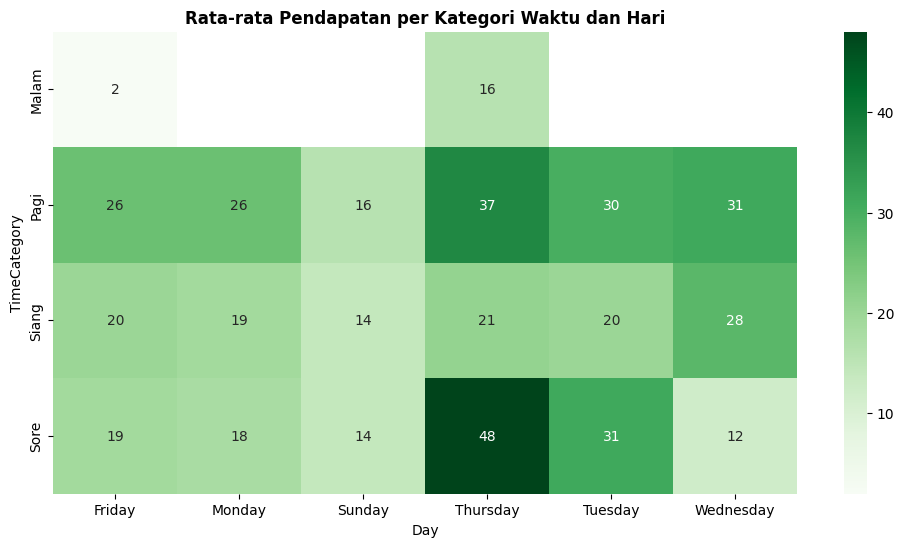

In [68]:
# Visualisasi
plt.figure(figsize=(12, 6))
sns.heatmap(ct_avg, annot=True, fmt=',.0f', cmap='Greens')
plt.title('Rata-rata Pendapatan per Kategori Waktu dan Hari', fontweight='bold')
plt.show()

Berdasarkan grafik di atas kita dapat mengetahui bahwa hari kamis ini memang memiliki revenue tertinggi hampir di semua kategori waktu dan yang tertinggi adalah ketika sore haria

3. Apa saja 5 produk dengan revenue tertinggi dan produk yang sering diorder?

In [69]:
# produk revenue tertinggi
top_5_products_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(5)
top_5_products_revenue

Description
WHITE HANGING HEART T-LIGHT HOLDER    3979.65
CREAM HEART CARD HOLDER               2462.16
SWEETHEART BIRD HOUSE                 2050.15
BLACK RECORD COVER FRAME              1819.92
JUMBO BAG RED RETROSPOT               1396.30
Name: Revenue, dtype: float64

In [70]:
# produk yang sering diorder 
top_5_products_ordered = df.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False).head(5).reset_index()
top_5_products_ordered.columns = ['Description', 'OrderCount']
top_5_products_ordered

,Description,OrderCount
0,JUMBO BAG RED RETROSPOT,24
1,PARTY BUNTING,22
2,REGENCY CAKESTAND 3 TIER,21
3,WHITE HANGING HEART T-LIGHT HOLDER,19
4,60 TEATIME FAIRY CAKE CASES,18


Kalo kita lihat di atas, produk JUMBO BAG RED RETROSPORT dan WHITE HANGING HEART T-LIGHT HOLDER adalah produk yang paling sering diorder dan juga memiliki revenue tertinggi. Produk ini mungkin cukup dibutuhkan di kalangan pelanggan sehingga kita bisa lebih memperhatikan produk ini dengan memperbanyak stok dan menawarkan harga khusus

4. Siapa saja top 10 custumer dengan revenue tertinggi?

In [71]:
top_customers = df.groupby('CustomerID').agg(
    total_orders=('InvoiceNo', 'count'),
    total_spent=('Revenue', 'sum'),
    avg_order_value=('Revenue', 'mean'),
    favorite_products=('Description', lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A')
).sort_values('total_spent', ascending=False).head(10).round(0)

print("🏆 Top 10 Customers:")
top_customers

🏆 Top 10 Customers:


,total_orders,total_spent,avg_order_value,favorite_products
CustomerID,,,,
17450,2,3521.0,1761.0,COOK WITH WINE METAL SIGN
15769,7,3509.0,501.0,CHILDRENS CUTLERY POLKADOT GREEN
14646,23,3480.0,151.0,BLUE POLKADOT CUP
18102,4,2940.0,735.0,BLACK HEART CARD HOLDER
14911,76,2150.0,28.0,WHITE HANGING HEART T-LIGHT HOLDER
16000,1,2046.0,2046.0,SWEETHEART BIRD HOUSE
14088,16,1900.0,119.0,BATHROOM SCALES RUBBER DUCKS
16210,2,1728.0,864.0,BLACK RECORD COVER FRAME
16029,9,1472.0,164.0,FRYING PAN UNION FLAG


Ini adalah customer dengan total spending tertinggi, jumlah order, rata-rata nilai order, dan produk favorit mereka. Informasi ini dapat membantu dalam strategi pemasaran dan penawaran khusus untuk pelanggan setia.

In [72]:
top_customers = df.groupby('CustomerID').agg(
    total_orders=('InvoiceNo', 'count'),
    total_spent=('Revenue', 'sum'),
    avg_order_value=('Revenue', 'mean'),
    favorite_products=('Description', lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A')
)

# Filter: minimal order 20 dan total spent di atas 1000
top_customers = top_customers[
    (top_customers['total_orders'] >= 20) & (top_customers['total_spent'] > 1000)
].sort_values('total_spent', ascending=False).head(10).round(0)

print("🏆 Top 10 Customers (Min. 20 Orders & Spent > £1000):")
top_customers


🏆 Top 10 Customers (Min. 20 Orders & Spent > £1000):


,total_orders,total_spent,avg_order_value,favorite_products
CustomerID,,,,
14646,23,3480.0,151.0,BLUE POLKADOT CUP
14911,76,2150.0,28.0,WHITE HANGING HEART T-LIGHT HOLDER
15311,28,1273.0,45.0,CHOCOLATE 3 WICK MORRIS BOX CANDLE


In [73]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Hour,Day,Month,Year,MonthName,TimeCategory,YearMonth,Revenue
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,17,Wednesday,5,2011,Mei,Sore,201105,2.08
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,11,Sunday,7,2011,Juli,Siang,201107,5.10
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,12,Tuesday,7,2011,Juli,Siang,201107,1.65
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,11,Wednesday,7,2011,Juli,Siang,201107,15.00
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,12,Sunday,2,2011,Februari,Siang,201102,2.55


In [74]:
import pandas as pd

# Pastikan InvoiceDate bertipe datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Tanggal referensi
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Customer summary
customer_summary = df.groupby('CustomerID').agg(
    recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    frequency=('InvoiceNo', 'nunique'),
    monetary=('Revenue', 'sum'),
    avg_order_value=('Revenue', 'mean'),
    unique_products=('Description', 'nunique'),
    favorite_product=('Description', lambda x: x.mode().iloc[0] if not x.mode().empty else 'N/A')
).reset_index()

threshold = customer_summary['monetary'].quantile(0.75)

customer_summary = customer_summary[
    customer_summary['monetary'] >= threshold
]

# RFM Scoring (1-5)
customer_summary['R_score'] = pd.qcut(
    customer_summary['recency'],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

customer_summary['F_score'] = pd.qcut(
    customer_summary['frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

customer_summary['M_score'] = pd.qcut(
    customer_summary['monetary'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Weighted Score
customer_summary['customer_score'] = (
    customer_summary['R_score'] * 0.25 +
    customer_summary['F_score'] * 0.35 +
    customer_summary['M_score'] * 0.40
)

# Top Customer
top_customers = (
    customer_summary
    .sort_values(['customer_score', 'monetary'], ascending=[False, False])
    .head(10)
    .round(2)
)


print("🏆 Top 10 Customers")
top_customers

🏆 Top 10 Customers


,CustomerID,recency,frequency,monetary,avg_order_value,unique_products,favorite_product,R_score,F_score,M_score,customer_score
752,14646,17,16,3479.53,151.28,23,BLUE POLKADOT CUP,5,5,5,5.0
837,14911,1,59,2149.65,28.28,69,WHITE HANGING HEART T-LIGHT HOLDER,5,5,5,5.0
560,14088,10,8,1900.38,118.77,14,BATHROOM SCALES RUBBER DUCKS,5,5,5,5.0
1664,17511,4,8,1334.64,111.22,12,CHRISTMAS STAR WISH LIST CHALKBOARD,5,5,5,5.0
961,15311,3,26,1273.09,45.47,26,CHOCOLATE 3 WICK MORRIS BOX CANDLE,5,5,5,5.0
471,13777,9,5,1160.60,232.12,4,JUMBO BAG RED RETROSPOT,5,5,5,5.0
895,15061,11,12,916.76,70.52,11,CLOTHES PEGS RETROSPOT PACK 24,5,5,5,5.0
562,14096,4,14,682.31,11.97,55,S/6 WOODEN SKITTLES IN COTTON BAG,5,5,5,5.0
1791,17841,2,63,669.17,6.03,102,CHILLI LIGHTS,5,5,5,5.0
250,13089,4,20,629.00,27.35,22,ROBOT BIRTHDAY CARD,5,5,5,5.0


In [75]:
print(
    customer_summary['monetary'].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

count     481.000000
mean      176.571684
std       381.542755
min        44.700000
25%        56.510000
50%        76.700000
75%       129.980000
90%       280.800000
95%       622.680000
max      3521.440000
Name: monetary, dtype: float64


In [76]:
pareto = customer_summary[['CustomerID', 'monetary']].copy()

pareto = pareto.sort_values(
    'monetary',
    ascending=False
)

pareto['cum_revenue_pct'] = (
    pareto['monetary'].cumsum()
    / pareto['monetary'].sum()
    * 100
)

pareto['cum_customer_pct'] = (
    range(1, len(pareto)+1)
)

pareto['cum_customer_pct'] = (
    pareto['cum_customer_pct']
    / len(pareto)
    * 100
)

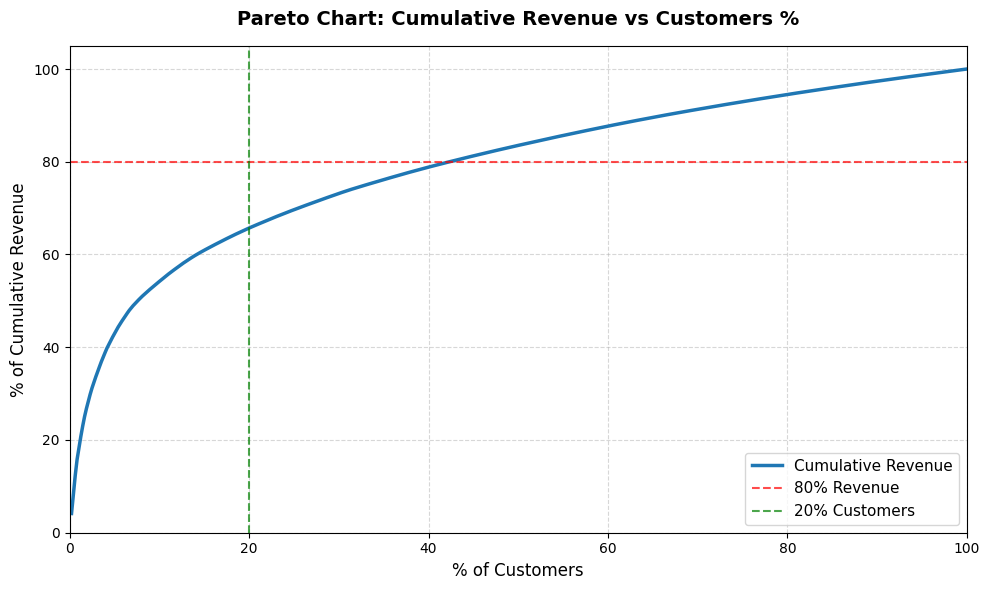

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Menyiapkan data Pareto
pareto = customer_summary[['CustomerID', 'monetary']].copy()
pareto = pareto.sort_values('monetary', ascending=False)
pareto['cum_revenue_pct'] = (pareto['monetary'].cumsum() / pareto['monetary'].sum()) * 100

# Menggunakan np.arange agar bisa langsung dibagi
pareto['cum_customer_pct'] = (np.arange(1, len(pareto) + 1) / len(pareto)) * 100

# 2. Membuat Line Chart
plt.figure(figsize=(10, 6))

# Plot kurva Pareto
plt.plot(
    pareto['cum_customer_pct'], 
    pareto['cum_revenue_pct'], 
    color='#1f77b4', 
    linewidth=2.5, 
    label='Cumulative Revenue'
)

# Menambahkan garis acuan Pareto (Aturan 80/20)
plt.axhline(80, color='red', linestyle='--', alpha=0.7, label='80% Revenue')
plt.axvline(20, color='green', linestyle='--', alpha=0.7, label='20% Customers')

# Menghias Chart
plt.title('Pareto Chart: Cumulative Revenue vs Customers %', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('% of Customers', fontsize=12)
plt.ylabel('% of Cumulative Revenue', fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

plt.show()


In [78]:
customer_revenue = (
    customer_summary[['CustomerID', 'monetary']]
    .sort_values('monetary', ascending=False)
)

top10_pct = (
    customer_revenue.head(10)['monetary'].sum()
    / customer_revenue['monetary'].sum()
    * 100
)

print(f"Top 10 customers contribute {top10_pct:.2f}% of revenue")

Top 10 customers contribute 28.35% of revenue
